# Analyse des paires ambiguës (cos_sim > 0.90)

**Question**: Combien de paires de MCP tools dans le vocab prod ont des embeddings quasi-identiques ?
Ces paires sont celles où le schema Jaccard pourrait aider à désambiguïer.

**Contexte**: Les embeddings BGE-M3 incluent déjà `name | description | param: desc` (voir `schemaToText`).
Donc si deux tools ont cos_sim > 0.90 malgré ça, c'est que l'embedding seul ne suffit pas.

In [1]:
import json
import numpy as np
import subprocess
from pathlib import Path
from collections import Counter

DATA_DIR = Path("../../gru/data")

# Load PML tool embeddings from DB
print("Loading PML tool embeddings from DB...")
result = subprocess.run(
    ['node', '-e', '''
const postgres = require("postgres");
const sql = postgres(process.env.DATABASE_URL);
(async () => {
  const rows = await sql`SELECT tool_id, embedding::text FROM tool_embedding ORDER BY tool_id`;
  const tools = {};
  for (const r of rows) {
    const emb = JSON.parse(r.embedding);
    if (emb.length === 1024) tools[r.tool_id] = emb;
  }
  process.stdout.write(JSON.stringify(tools));
  await sql.end();
})();
'''],
    capture_output=True, text=True,
    env={**__import__('os').environ},
    cwd=str(Path.home() / 'CascadeProjects/AgentCards')
)
pml_tools = json.loads(result.stdout)
pml_ids = list(pml_tools.keys())
pml_embs = np.array([pml_tools[k] for k in pml_ids], dtype=np.float32)
print(f"PML tools: {len(pml_ids)}, dim: {pml_embs.shape[1]}")

# Load Smithery additions from expanded vocab
with open(DATA_DIR / "expanded-vocab.json") as f:
    vocab = json.load(f)
smithery_ids = vocab["smitheryToolIds"]
smithery_embs = np.array(vocab["smitheryToolEmbeddings"], dtype=np.float32)
print(f"Smithery additions: {len(smithery_ids)}")

# Combine into full vocab
all_ids = pml_ids + smithery_ids
all_embs = np.vstack([pml_embs, smithery_embs])
print(f"Total vocab: {len(all_ids)} tools, {all_embs.shape[1]}D")

Loading PML tool embeddings from DB...
PML tools: 644, dim: 1024
Smithery additions: 1240
Total vocab: 1884 tools, 1024D


In [2]:
# Normalize and compute full pairwise cosine similarity
norms = np.linalg.norm(all_embs, axis=1, keepdims=True)
all_norm = all_embs / norms

print(f"Computing {len(all_ids)}x{len(all_ids)} pairwise cosine similarity...")
sim = all_norm @ all_norm.T
np.fill_diagonal(sim, 0)  # ignore self-similarity

# Count pairs above thresholds
thresholds = [0.85, 0.88, 0.90, 0.92, 0.95, 0.98]
print("\n=== Paires de MCP tools par seuil de similarité ===")
for t in thresholds:
    # Upper triangle only (avoid double-counting)
    mask = np.triu(sim > t, k=1)
    n_pairs = mask.sum()
    # How many unique tools are involved?
    involved = set()
    rows, cols = np.where(mask)
    for r, c in zip(rows, cols):
        involved.add(r)
        involved.add(c)
    print(f"  cos_sim > {t:.2f}: {n_pairs:>6} paires, {len(involved):>5} tools impliqués ({len(involved)/len(all_ids)*100:.1f}%)")

# Focus on > 0.90 (the threshold experts proposed)
mask_090 = np.triu(sim > 0.90, k=1)
rows_090, cols_090 = np.where(mask_090)
print(f"\n>>> {len(rows_090)} paires avec cos_sim > 0.90 <<<")

Computing 1884x1884 pairwise cosine similarity...

=== Paires de MCP tools par seuil de similarité ===
  cos_sim > 0.85:  11528 paires,  1796 tools impliqués (95.3%)
  cos_sim > 0.88:   3640 paires,  1518 tools impliqués (80.6%)
  cos_sim > 0.90:   1833 paires,  1213 tools impliqués (64.4%)
  cos_sim > 0.92:    841 paires,   819 tools impliqués (43.5%)
  cos_sim > 0.95:    145 paires,   241 tools impliqués (12.8%)
  cos_sim > 0.98:      8 paires,    16 tools impliqués (0.8%)

>>> 1833 paires avec cos_sim > 0.90 <<<


In [3]:
# Show the most ambiguous pairs (cos_sim > 0.90)
pairs_090 = []
for r, c in zip(rows_090, cols_090):
    pairs_090.append((sim[r, c], all_ids[r], all_ids[c]))
pairs_090.sort(reverse=True)

print(f"=== Top 40 paires les plus similaires (cos_sim > 0.90) ===")
print(f"{'Sim':>6}  Tool A  →  Tool B")
print("-" * 100)
for s, a, b in pairs_090[:40]:
    print(f"{s:.4f}  {a}  →  {b}")

print(f"\n... et {len(pairs_090) - 40} paires de plus" if len(pairs_090) > 40 else "")

=== Top 40 paires les plus similaires (cos_sim > 0.90) ===
   Sim  Tool A  →  Tool B
----------------------------------------------------------------------------------------------------
0.9859  kamath/agentmail-mcps:reply_to_message  →  agentmail:reply_to_message
0.9852  std:geo_decimal_to_dms  →  std:geo_dms_to_decimal
0.9841  brightdata:scrape_batch  →  brightdata:scrape_as_markdown
0.9822  std:which  →  std:which_command
0.9812  std:color_hex_to_rgb  →  std:color_rgb_to_hex
0.9808  std:color_cmyk_to_rgb  →  std:color_rgb_to_cmyk
0.9807  KaranThink41/official-slack-mcp:reply_to_thread_on_slack  →  KaranThink41/official-slack-mcp:get_thread_replies_on_slack
0.9806  std:color_hsv_to_rgb  →  std:color_rgb_to_hsv
0.9789  shopify:SHOPIFY_GET_PRODUCT  →  shopify:SHOPIFY_GET_PRODUCTS
0.9773  barryyip0625/mcp-discord:discord_send  →  wowjinxy/mcp-discord:send_message
0.9772  clickup:CLICKUP_FOLDERS_CREATE_NEW_FOLDER  →  clickup:CLICKUP_CREATE_FOLDER
0.9758  node2flow/airtable:airtable_create

In [4]:
# Cluster the ambiguous tools: connected components where cos_sim > 0.90
# This shows groups of tools that are all similar to each other
from collections import defaultdict

adj = defaultdict(set)
for r, c in zip(rows_090, cols_090):
    adj[r].add(c)
    adj[c].add(r)

# BFS to find connected components
visited = set()
clusters = []
for node in adj:
    if node in visited:
        continue
    cluster = []
    queue = [node]
    while queue:
        n = queue.pop(0)
        if n in visited:
            continue
        visited.add(n)
        cluster.append(n)
        queue.extend(adj[n] - visited)
    clusters.append(sorted(cluster))

clusters.sort(key=len, reverse=True)

print(f"=== Clusters d'outils ambigus (cos_sim > 0.90) ===")
print(f"{len(clusters)} clusters, tailles: {[len(c) for c in clusters[:20]]}")
print()

for i, cluster in enumerate(clusters[:15]):
    tools = [all_ids[idx] for idx in cluster]
    # Extract common service prefix
    servers = set(t.split(':')[0] for t in tools)
    print(f"Cluster {i+1} ({len(cluster)} tools, servers: {servers}):")
    for t in tools[:10]:
        print(f"  - {t}")
    if len(tools) > 10:
        print(f"  ... +{len(tools)-10} more")
    print()

=== Clusters d'outils ambigus (cos_sim > 0.90) ===
225 clusters, tailles: [266, 66, 61, 29, 27, 26, 16, 13, 13, 12, 11, 11, 11, 10, 10, 9, 9, 9, 9, 8]

Cluster 1 (266 tools, servers: {'emmanuel/projects-emmanuel', 'agentidx/agentcrawl', 'node2flow/notion', 'PostHog', 'linear', 'kodey-ai/upload-post-mcp', 'clickup', 'arturwyroslak/ai-agent-generator-mcp', 'zoho_books', 'quickbooks', 'taazkareem/clickup-mcp-premium', 'huuthangntk/dokploy-mcp', 'NOVA-3951/fastmail', 'lumberjack-so/joemcp', 'Polaralias/clickup-mcp', 'zereight/sentry-mcp', 'kamath/agentmail-mcps', 'omd01/aws-ses-mcp', 'intercom', 'harvest', 'mike/courier', 'pixelsock/directus-mcp', 'googlecalendar', 'Geralt1983/mcp-todoist', 'googleads', 'Chrusic/todoist-mcp-server-extended', 'muammar-yacoob/gmail-manager-mcp', 'Ejb503/systemprompt-mcp-taskchecker', 'samihalawa/brevo-mcp', 'rishipradeep-think41/google-calendar-mcp', 'googletasks', 'aggKartik/notion-proxy-unofficial', 'wrike', 'access/blooio', 'todoist', 'asana', 'freebreake

In [5]:
# For pairs with cos_sim > 0.90: does schema Jaccard actually separate them?
# Load schemas for PML tools from DB + Smithery from catalog

# PML schemas from DB
print("Loading PML input schemas from DB...")
result2 = subprocess.run(
    ['node', '-e', '''
const postgres = require("postgres");
const sql = postgres(process.env.DATABASE_URL);
(async () => {
  const rows = await sql`SELECT tool_id, input_schema::text as s FROM tool_schema WHERE input_schema IS NOT NULL`;
  const schemas = {};
  for (const r of rows) {
    try {
      const parsed = JSON.parse(r.s);
      if (parsed.properties) schemas[r.tool_id] = Object.keys(parsed.properties);
    } catch {}
  }
  process.stdout.write(JSON.stringify(schemas));
  await sql.end();
})();
'''],
    capture_output=True, text=True,
    env={**__import__('os').environ},
    cwd=str(Path.home() / 'CascadeProjects/AgentCards')
)
pml_schemas = json.loads(result2.stdout)
print(f"PML tools with params: {len(pml_schemas)}")

# Smithery schemas from catalog
smithery_schemas = {}
catalog_path = DATA_DIR / "smithery-mcp-tools.json"
if catalog_path.exists():
    with open(catalog_path) as f:
        catalog = json.load(f)
    for t in catalog['tools']:
        props = t.get('inputSchema', {}).get('properties', {})
        if props:
            smithery_schemas[t['id']] = list(props.keys())
print(f"Smithery tools with params: {len(smithery_schemas)}")

# Merge
all_schemas = {**pml_schemas, **smithery_schemas}
print(f"Total tools with schema: {len(all_schemas)}")

# Normalize param names (same as TS: camelCase split, lowercase)
import re
def normalize_params(params):
    tokens = set()
    for p in params:
        parts = re.sub(r'([a-z])([A-Z])', r'\1_\2', p).lower().split('_')
        tokens.update(parts)
    return tokens

# For each pair with cos_sim > 0.90, compute schema Jaccard
jaccard_scores = []
both_have_schema = 0
one_missing = 0

for s, a, b in pairs_090:
    params_a = all_schemas.get(a)
    params_b = all_schemas.get(b)
    if params_a is None or params_b is None:
        one_missing += 1
        jaccard_scores.append((s, a, b, None))
        continue
    
    both_have_schema += 1
    tokens_a = normalize_params(params_a)
    tokens_b = normalize_params(params_b)
    
    if len(tokens_a | tokens_b) == 0:
        jaccard_scores.append((s, a, b, 1.0))  # both empty = identical
        continue
    
    jaccard = len(tokens_a & tokens_b) / len(tokens_a | tokens_b)
    jaccard_scores.append((s, a, b, jaccard))

print(f"\n=== Schema Jaccard pour les {len(pairs_090)} paires cos_sim > 0.90 ===")
print(f"Les deux ont un schema: {both_have_schema} ({both_have_schema/max(len(pairs_090),1)*100:.1f}%)")
print(f"Au moins un sans schema: {one_missing} ({one_missing/max(len(pairs_090),1)*100:.1f}%)")

# Stats on Jaccard where both have schema
jaccards = [j for _, _, _, j in jaccard_scores if j is not None]
if jaccards:
    jaccards = np.array(jaccards)
    print(f"\nJaccard stats (N={len(jaccards)}):")
    print(f"  Mean: {jaccards.mean():.3f}")
    print(f"  Median: {np.median(jaccards):.3f}")
    print(f"  Jaccard < 0.3 (schemas tres differents): {(jaccards < 0.3).sum()} ({(jaccards < 0.3).mean()*100:.1f}%)")
    print(f"  Jaccard 0.3-0.7 (partiellement differents): {((jaccards >= 0.3) & (jaccards < 0.7)).sum()}")
    print(f"  Jaccard >= 0.7 (schemas similaires): {(jaccards >= 0.7).sum()} ({(jaccards >= 0.7).mean()*100:.1f}%)")
    print(f"  Jaccard == 1.0 (schemas identiques): {(jaccards == 1.0).sum()}")
    print(f"\n→ Jaccard < 0.3 = le schema POURRAIT séparer ces tools")
    print(f"→ Jaccard >= 0.7 = le schema ne sépare PAS (mêmes params)")

Loading PML input schemas from DB...
PML tools with params: 610
Smithery tools with params: 15332
Total tools with schema: 15939

=== Schema Jaccard pour les 1833 paires cos_sim > 0.90 ===
Les deux ont un schema: 1744 (95.1%)
Au moins un sans schema: 89 (4.9%)

Jaccard stats (N=1744):
  Mean: 0.365
  Median: 0.286
  Jaccard < 0.3 (schemas tres differents): 906 (51.9%)
  Jaccard 0.3-0.7 (partiellement differents): 555
  Jaccard >= 0.7 (schemas similaires): 283 (16.2%)
  Jaccard == 1.0 (schemas identiques): 232

→ Jaccard < 0.3 = le schema POURRAIT séparer ces tools
→ Jaccard >= 0.7 = le schema ne sépare PAS (mêmes params)


In [6]:
# Show pairs where cos_sim > 0.90 BUT schema Jaccard < 0.3
# These are the ones where schema reranking would ACTUALLY help

separable = [(s, a, b, j) for s, a, b, j in jaccard_scores if j is not None and j < 0.3]
separable.sort(key=lambda x: x[0], reverse=True)

print(f"=== Paires séparables par schema (cos > 0.90, Jaccard < 0.3): {len(separable)} ===")
print(f"{'CosSim':>6} {'Jaccard':>7}  Tool A  →  Tool B  [params A] vs [params B]")
print("-" * 120)
for s, a, b, j in separable[:30]:
    pa = all_schemas.get(a, [])
    pb = all_schemas.get(b, [])
    print(f"{s:.4f} {j:.3f}    {a}  →  {b}")
    print(f"         A: {pa[:5]}{'...' if len(pa)>5 else ''}")
    print(f"         B: {pb[:5]}{'...' if len(pb)>5 else ''}")

# Non-separable: same schema, same embedding = truly redundant
nonsep = [(s, a, b, j) for s, a, b, j in jaccard_scores if j is not None and j >= 0.7]
print(f"\n=== NON-séparables (cos > 0.90 ET Jaccard >= 0.7): {len(nonsep)} ===")
print("→ Ces tools sont probablement des vrais doublons (même fonction, serveurs différents)")
for s, a, b, j in nonsep[:15]:
    print(f"  {s:.4f} J={j:.2f}  {a}  →  {b}")

=== Paires séparables par schema (cos > 0.90, Jaccard < 0.3): 906 ===
CosSim Jaccard  Tool A  →  Tool B  [params A] vs [params B]
------------------------------------------------------------------------------------------------------------------------
0.9852 0.000    std:geo_decimal_to_dms  →  std:geo_dms_to_decimal
         A: ['type', 'decimal']
         B: ['degrees', 'minutes', 'seconds', 'direction']
0.9841 0.000    brightdata:scrape_batch  →  brightdata:scrape_as_markdown
         A: ['urls']
         B: ['url']
0.9812 0.000    std:color_hex_to_rgb  →  std:color_rgb_to_hex
         A: ['hex']
         B: ['b', 'g', 'r']
0.9808 0.000    std:color_cmyk_to_rgb  →  std:color_rgb_to_cmyk
         A: ['c', 'k', 'm', 'y']
         B: ['b', 'g', 'r']
0.9806 0.000    std:color_hsv_to_rgb  →  std:color_rgb_to_hsv
         A: ['h', 's', 'v']
         B: ['b', 'g', 'r']
0.9789 0.000    shopify:SHOPIFY_GET_PRODUCT  →  shopify:SHOPIFY_GET_PRODUCTS
         A: ['product_id']
         B: ['ids']


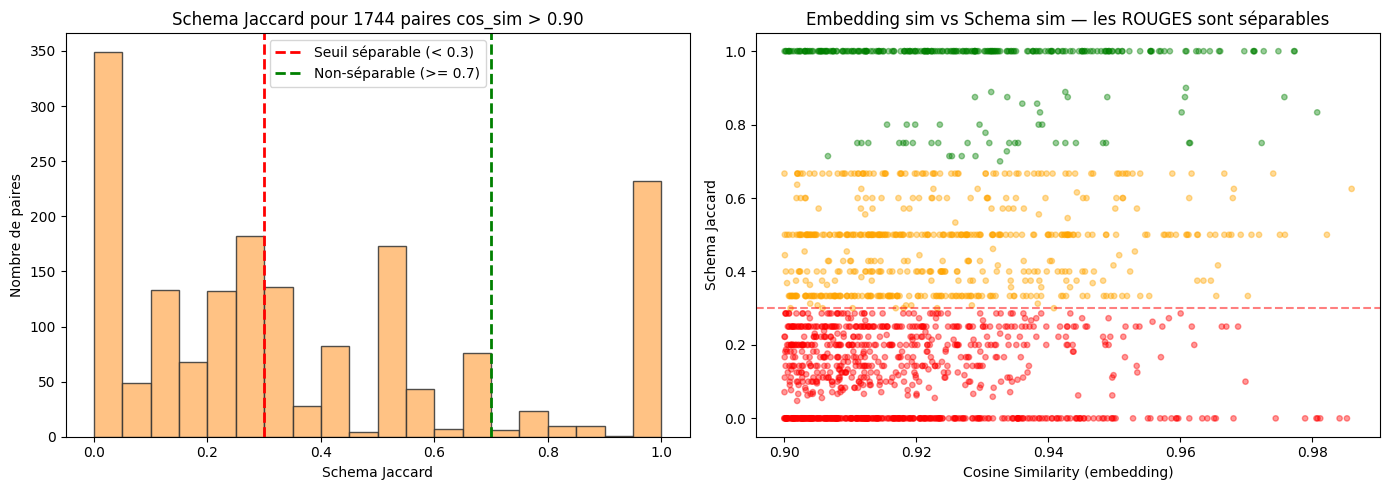


VERDICT
Paires cos_sim > 0.90:         1833
Séparables par schema:         906 (49.4%)
Non-séparables (vrais doublons): 283 (15.4%)

→ Si séparables > 100: schema reranker justifié
→ Si séparables < 30: pas worth it, focus sur data


In [7]:
# Final summary
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des Jaccard pour paires > 0.90
if len(jaccards) > 0:
    ax = axes[0]
    ax.hist(jaccards, bins=20, color='#FFB86F', edgecolor='#333', alpha=0.85)
    ax.axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='Seuil séparable (< 0.3)')
    ax.axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Non-séparable (>= 0.7)')
    ax.set_xlabel('Schema Jaccard')
    ax.set_ylabel('Nombre de paires')
    ax.set_title(f'Schema Jaccard pour {len(jaccards)} paires cos_sim > 0.90')
    ax.legend()

# Scatter: cosine sim vs Jaccard
ax2 = axes[1]
cos_vals = [s for s, _, _, j in jaccard_scores if j is not None]
jac_vals = [j for _, _, _, j in jaccard_scores if j is not None]
colors = ['red' if j < 0.3 else 'orange' if j < 0.7 else 'green' for j in jac_vals]
ax2.scatter(cos_vals, jac_vals, c=colors, alpha=0.4, s=15)
ax2.set_xlabel('Cosine Similarity (embedding)')
ax2.set_ylabel('Schema Jaccard')
ax2.set_title('Embedding sim vs Schema sim — les ROUGES sont séparables')
ax2.axhline(y=0.3, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ambiguous-pairs.png', dpi=150)
plt.show()

print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
n_total = len(pairs_090)
n_separable = len(separable)
n_nonsep = len(nonsep)
print(f"Paires cos_sim > 0.90:         {n_total}")
print(f"Séparables par schema:         {n_separable} ({n_separable/max(n_total,1)*100:.1f}%)")
print(f"Non-séparables (vrais doublons): {n_nonsep} ({n_nonsep/max(n_total,1)*100:.1f}%)")
print(f"\n→ Si séparables > 100: schema reranker justifié")
print(f"→ Si séparables < 30: pas worth it, focus sur data")